In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Tesis/book30-listing-train.csv", sep=';')

df.head()

,Amazon Index (ASIN),Filename,Image URL,Title,Author,Category ID,Category
0,1588345297,1588345297.jpg,http://ecx.images-amazon.com/images/I/51l6XIoa...,With Schwarzkopf: Life Lessons of The Bear,Gus Lee,1,Biographies & Memoirs
1,1404803335,1404803335.jpg,http://ecx.images-amazon.com/images/I/51UJnL3T...,"Magnets: Pulling Together, Pushing Apart (Amaz...",Natalie M. Rosinsky,4,Children's Books
2,1446276082,1446276082.jpg,http://ecx.images-amazon.com/images/I/51MGUKhk...,Energy Security (SAGE Library of International...,NaN,10,Engineering & Transportation
3,1491522666,1491522666.jpg,http://ecx.images-amazon.com/images/I/51qKvjsi...,An Amish Gathering: Life in Lancaster County,Beth Wiseman,9,Christian Books & Bibles
4,970096410,0970096410.jpg,http://ecx.images-amazon.com/images/I/51qoUENb...,City of Rocks Idaho: A Climber's Guide (Region...,Dave Bingham,26,Sports & Outdoors


### Información General del DataFrame

Primero, veamos la información general del DataFrame, incluyendo el tipo de dato de cada columna y la cantidad de valores no nulos.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51300 entries, 0 to 51299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Amazon Index (ASIN)  51300 non-null  object
 1   Filename             51300 non-null  object
 2   Image URL            51300 non-null  object
 3   Title                51300 non-null  object
 4   Author               47861 non-null  object
 5   Category ID          51300 non-null  int64 
 6   Category             51300 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.7+ MB


### Estadísticas Descriptivas

Ahora, generemos un resumen estadístico de las columnas numéricas para entender su distribución central, dispersión y forma.

In [7]:
df.describe(include='all')

,Amazon Index (ASIN),Filename,Image URL,Title,Author,Category ID,Category
count,51300,51300,51300,51300,47861,51300.000000,51300
unique,51300,51300,51286,51001,35957,NaN,30
top,045147483X,045147483X.jpg,http://ecx.images-amazon.com/images/I/41qESfen...,The Tibetan Book of the Dead,Kaplan,NaN,Biographies & Memoirs
freq,1,1,3,4,112,NaN,1710
mean,NaN,NaN,NaN,NaN,NaN,14.500000,NaN
std,NaN,NaN,NaN,NaN,NaN,8.655526,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,7.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,14.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,22.000000,NaN


### Verificación de Valores Nulos

Es crucial identificar si hay valores faltantes en el dataset y en qué columnas se encuentran. Esto nos ayudará a planificar el preprocesamiento de datos.

In [8]:
print(df.isnull().sum())
print('\nPorcentaje de valores nulos:')
print((df.isnull().sum() / len(df)) * 100)

Amazon Index (ASIN)       0
Filename                  0
Image URL                 0
Title                     0
Author                 3439
Category ID               0
Category                  0
dtype: int64

Porcentaje de valores nulos:
Amazon Index (ASIN)    0.000000
Filename               0.000000
Image URL              0.000000
Title                  0.000000
Author                 6.703704
Category ID            0.000000
Category               0.000000
dtype: float64


### Verificación de Integridad de URLs de Imágenes

Vamos a verificar la accesibilidad de una muestra de `Image URL`s para evaluar la integridad de las portadas. Esto implica hacer peticiones HTTP a cada URL.

In [11]:
import requests
import numpy as np

def check_image_url(url):
    """Verifica la accesibilidad de una URL de imagen."""
    try:
        # Configura un tiempo de espera (timeout) para evitar esperas infinitas
        response = requests.head(url, timeout=5) # requests.head es más eficiente que requests.get para solo verificar el estado
        return response.status_code
    except requests.exceptions.RequestException:
        return None # Retorna None en caso de cualquier error de petición

# Tomar una muestra aleatoria para no saturar con demasiadas peticiones
sample_size = 250 # Puedes ajustar este número
sample_urls = df['Image URL'].sample(min(sample_size, len(df)), random_state=42)

print(f"Verificando {len(sample_urls)} URLs de imágenes. Esto puede tomar un momento...")

# Aplicar la función a la muestra de URLs
url_status = sample_urls.apply(check_image_url)

# Analizar los resultados
valid_urls = url_status[url_status == 200].count()
not_found_urls = url_status[url_status == 404].count()
other_errors = url_status[url_status.isin(np.arange(400, 600)) & (url_status != 404)].count()
network_errors = url_status[url_status.isnull()].count()

print(f"\nResultados de la verificación de URLs (muestra de {len(sample_urls)}):")
print(f"  - URLs válidas (HTTP 200 OK): {valid_urls}")
print(f"  - URLs no encontradas (HTTP 404 Not Found): {not_found_urls}")
print(f"  - Otros errores HTTP (4xx, 5xx): {other_errors}")
print(f"  - Errores de conexión/red: {network_errors}")

# Mostrar algunas URLs con errores (si las hay)
if network_errors > 0 or not_found_urls > 0 or other_errors > 0:
    print("\nEjemplos de URLs con problemas:")
    problem_urls = sample_urls[url_status.isnull() | (url_status != 200)]
    for i, url in enumerate(problem_urls.head(5)):
        status = url_status.loc[problem_urls.index[i]]
        print(f"  - {url} (Estado: {status if status else 'Error de red'})")

Verificando 250 URLs de imágenes. Esto puede tomar un momento...

Resultados de la verificación de URLs (muestra de 250):
  - URLs válidas (HTTP 200 OK): 250
  - URLs no encontradas (HTTP 404 Not Found): 0
  - Otros errores HTTP (4xx, 5xx): 0
  - Errores de conexión/red: 0


### Distribución de Libros por Categoría

Ahora, visualicemos la cantidad de libros que hay en cada categoría para entender la distribución temática de nuestro dataset.

/tmp/ipykernel_18126/248070551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Category', order=df['Category'].value_counts().index, palette='viridis')


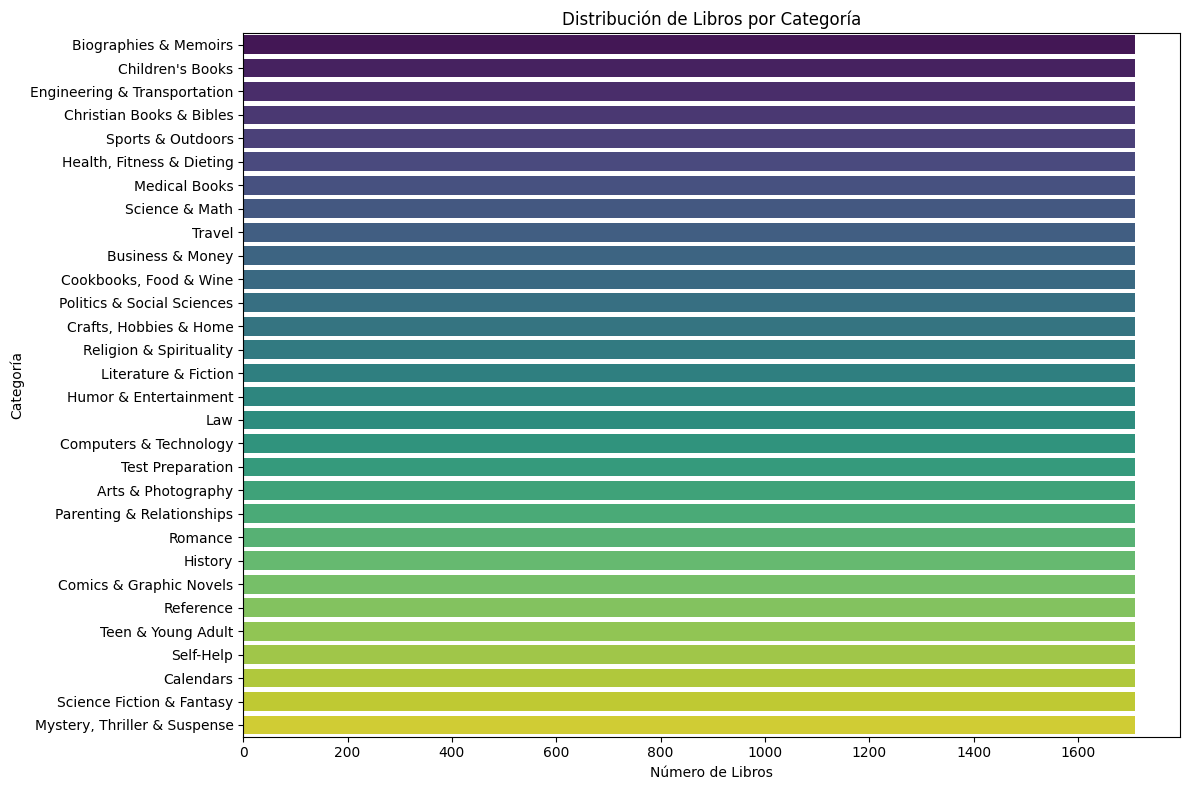

In [10]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='Category', order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribución de Libros por Categoría')
plt.xlabel('Número de Libros')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()